# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

In [3]:
# Завантажуємо дані
df = pd.read_csv('/content/drive/MyDrive/Analytics_HW/credit_risk_dataset.csv')

print(f"Розмір датасету: {df.shape}")
print(f"Кількість клієнтів: {df.shape[0]:,}")
print(f"Кількість ознак: {df.shape[1]}")

Розмір датасету: (32581, 12)
Кількість клієнтів: 32,581
Кількість ознак: 12


In [4]:
# Перші 5 рядків даних
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
#Типи даних (кількість записів,типи колонок)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
# Розподіл відтоку
churn_dist = df['loan_status'].value_counts()
churn_percent = df['loan_status'].value_counts(normalize=True) * 100

churn_percent

,proportion
loan_status,
0,78.183604
1,21.816396


**Висновок:** Маємо справу з незбалансованим датасетом (78% vs 21%). Отже, маємо справу з задачею незбалансованої класифікації.


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [7]:
# Перевірка пропущених значень
missing = df.isnull().sum()
missing[missing > 0]

,0
person_emp_length,895
loan_int_rate,3116


In [8]:
# Рахую відсоток пропущенних значень
missing_percent = df.isnull().mean() * 100
missing_percent[missing_percent > 0]

,0
person_emp_length,2.747000
loan_int_rate,9.563856


In [9]:
# Заповнюю пропуски (числові)
df.fillna(df.median(numeric_only=True), inplace=True)

In [10]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
# Перевіряю, чи тепер все покращилось і пропущенних значень більше немає
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [12]:
# Аналіз розподілу числових змінних
df.select_dtypes("number").describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [13]:
# Обробка викидів в колонці person_income з допомогою Interquartile range
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(-22550.0), np.float64(140250.0))

In [14]:
# Знаходжу викиди
outliers = df[(df['person_income'] < lower_bound) |
              (df['person_income'] > upper_bound)]

outliers.shape

(1484, 12)

In [15]:
#Обробляю викиди за допомогою медіани
median = df['person_income'].median()

df.loc[df['person_income'] > upper_bound, 'person_income'] = median
df.loc[df['person_income'] < lower_bound, 'person_income'] = median

**Висновок:** Викиди в колонці person_income були виявлені за допомогою методу міжквартильного розмаху (IQR). Значення, що виходили за межі [Q1 - 1.5×IQR; Q3 + 1.5×IQR], були оброблені методом заповнення медіани.

In [16]:
# Знаходжу категоріальні колонки
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [17]:
# Частота значень
for col in cat_cols:
    print(f'\n{col}')
    print(df[col].value_counts(normalize=True) * 100)


person_home_ownership
person_home_ownership
RENT        50.477272
MORTGAGE    41.263313
OWN          7.931003
OTHER        0.328412
Name: proportion, dtype: float64

loan_intent
loan_intent
EDUCATION            19.806022
MEDICAL              18.633559
VENTURE              17.553175
PERSONAL             16.945459
DEBTCONSOLIDATION    15.997053
HOMEIMPROVEMENT      11.064731
Name: proportion, dtype: float64

loan_grade
loan_grade
A    33.077561
B    32.076977
C    19.821368
D    11.129186
E     2.958780
F     0.739695
G     0.196434
Name: proportion, dtype: float64

cb_person_default_on_file
cb_person_default_on_file
N    82.367024
Y    17.632976
Name: proportion, dtype: float64


In [18]:
fig = px.box(
    df,
    x='loan_status',
    y='loan_int_rate',
    title='Процентна ставка vs дефолт',
    labels={
        'loan_status': 'Дефолт',
        'loan_int_rate': 'Ставка (%)'
    },
    color='loan_status',
    color_discrete_map={
        0: '#34495e',
        1: '#e67e22'
    }
)

fig.show()

**Висновок:** Клієнти з дефолтом мають вищі процентні ставки, ніж ті, хто повертає кредит.

In [19]:
col = 'loan_grade'

temp = df.groupby([col, 'loan_status']).size().unstack()
temp_pct = temp.div(temp.sum(axis=1), axis=0) * 100

fig = px.bar(
    temp_pct,
    barmode='group',
    title='Дефолт за кредитним рейтингом',
    labels={
        'value': 'Відсоток (%)',
        'loan_grade': 'Рейтинг'
    },
    color_discrete_map={
        0: '#2ecc71',
        1: '#e74c3c'
    }
)

fig.show()

**Висновок:** Чим гірший кредитний рейтинг (від A до G), тим значно вища ймовірність дефолту.

In [20]:
col = 'person_home_ownership'

temp = df.groupby([col, 'loan_status']).size().unstack()
temp_pct = temp.div(temp.sum(axis=1), axis=0) * 100

fig = px.bar(
    temp_pct,
    barmode='group',
    title='Дефолт за типом житла',
    labels={
        'value': 'Відсоток (%)',
        'person_home_ownership': 'Тип житла'
    },
    color_discrete_map={
        0: '#8e44ad',
        1: '#ff6b81'
    }
)

fig.show()

**Висновок:** Клієнти, які орендують житло (RENT), частіше допускають дефолт, ніж власники (OWN, MORTGAGE).


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



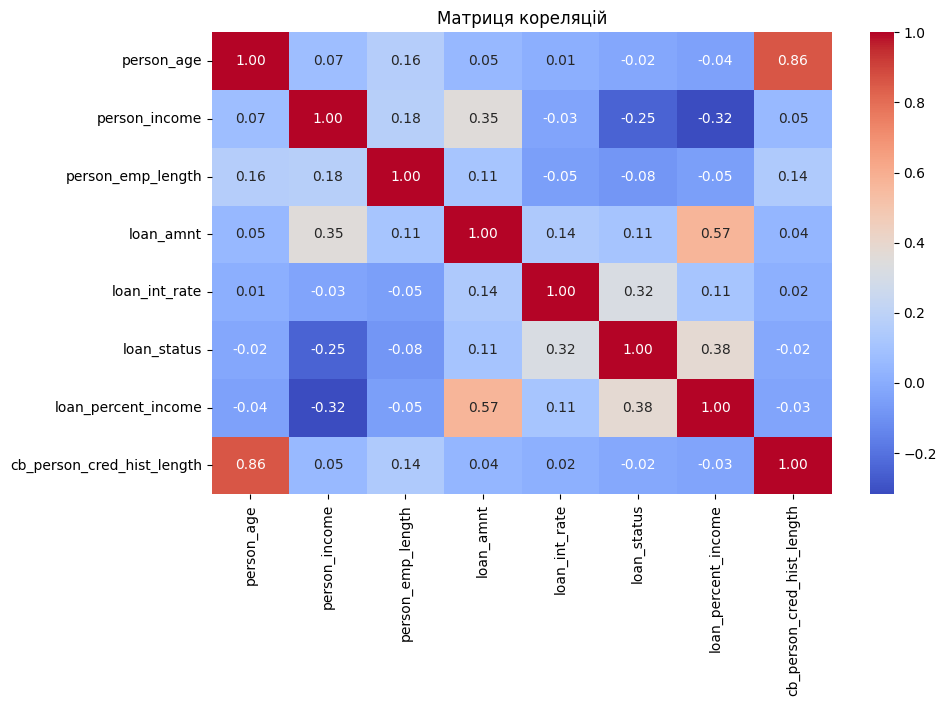

In [21]:
# Будую кореляційну матрицю
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Матриця кореляцій")
plt.show()

**Висновок:** Найбільший вплив на дефолт мають процентна ставка та частка доходу, тоді як більшість інших змінних мають слабкий зв’язок із цільовою змінною.

In [22]:
# Кодування категоріальних змінних (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

In [23]:
# Перевірка
df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True


In [24]:
# Фінальний набір ознак
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")

Кількість ознак: 22
Розмір вибірки: 32581


In [25]:
X.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True


**Висновок:** Для моделювання було використано всі доступні ознаки після кодування категоріальних змінних, оскільки вони можуть містити корисну інформацію для прогнозування дефолту.


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [26]:
# Розділяємо дані на X та Y та ділимо на тестовута тренувальну вибірки

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} клієнтів")
print(f"Test: {X_test.shape[0]} клієнтів")
print(f"Дефолт в train: {y_train.mean():.1%}")
print(f"Дефолт в test: {y_test.mean():.1%}")

Train: 26064 клієнтів
Test: 6517 клієнтів
Дефолт в train: 21.8%
Дефолт в test: 21.8%


In [27]:
# Масштабування
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

# Створю та навчаю модель
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Модель навчена!")

Модель навчена!


In [29]:
model

LogisticRegression(max_iter=1000, random_state=42)

In [30]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [31]:
# Ймовірності для test
y_pred_proba = model.predict_proba(X_test_scaled)

test_predictions = pd.DataFrame({
    'Реальний': y_test.values[:5],
    'Прогноз': y_test_pred[:5],
    'Ймовірність 0': y_pred_proba[:5, 0].round(3),
    'Ймовірність 1': y_pred_proba[:5, 1].round(3)
})

print("\nTest predictions:")
print(test_predictions)


Test predictions:
   Реальний  Прогноз  Ймовірність 0  Ймовірність 1
0         0        0          0.887          0.113
1         0        0          0.913          0.087
2         0        0          0.984          0.016
3         0        0          0.934          0.066
4         0        0          0.993          0.007


In [32]:
# Ймовірності для train
y_train_proba = model.predict_proba(X_train_scaled)

train_predictions = pd.DataFrame({
    'Реальний': y_train.values[:5],
    'Прогноз': y_train_pred[:5],
    'Ймовірність 0': y_train_proba[:5, 0].round(3),
    'Ймовірність 1': y_train_proba[:5, 1].round(3)
})

print("Train predictions:")
print(train_predictions)

Train predictions:
   Реальний  Прогноз  Ймовірність 0  Ймовірність 1
0         0        0          0.991          0.009
1         1        0          0.858          0.142
2         0        0          0.757          0.243
3         1        0          0.809          0.191
4         0        0          0.959          0.041


In [33]:
# Приклад прогнозів для перших 5 клієнтів
sample_predictions = pd.DataFrame({
    'Реальний': y_test.values[:5],
    'Прогноз': y_test_pred[:5],
    'Ймовірність 0': y_pred_proba[:5, 0].round(3),
    'Ймовірність 1': y_pred_proba[:5, 1].round(3)
})

print(sample_predictions)

   Реальний  Прогноз  Ймовірність 0  Ймовірність 1
0         0        0          0.887          0.113
1         0        0          0.913          0.087
2         0        0          0.984          0.016
3         0        0          0.934          0.066
4         0        0          0.993          0.007


**Висновок:** Дані були розділені на навчальну та тестову вибірки у співвідношенні 80/20.
До числових ознак було застосовано масштабування.
Було навчено модель логістичної регресії, після чого отримано прогнози класів та ймовірностей для тестової та тренувальної вибірки за допомогою моделі логістичної регресії.


---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


Перетворюю задачу в класифікацію (дорога квартира чи ні), роблю всі необхідні дії для цього.

In [36]:
# Створю binary target.
# Поріг — медіана
threshold = y.median()

y_class = (y > threshold).astype(int)

In [37]:
# Розділюю дані
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

In [38]:
# Будую модель (логістична регресія)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression(max_iter=1000)

In [39]:
# Прогнози
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

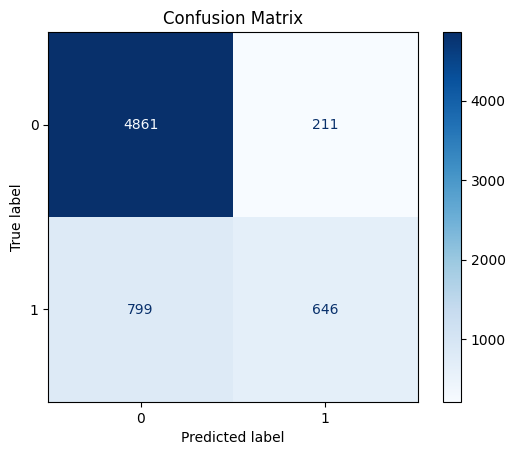

In [40]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix')
plt.show()

Матриця помилок показує, що модель:
правильно класифікує більшість негативних випадків (4861);
робить відносно мало хибно-позитивних прогнозів (211),
але має значну кількість хибно-негативних (799), тобто пропускає важливі випадки;
правильно визначає лише 646 позитивних випадків.

**Висновок:** модель консервативна — боїться “помилитись у плюс”, тому часто не помічає позитивний клас

In [41]:
# Метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.8450207150529385
Precision: 0.7537922987164527
Recall: 0.4470588235294118
F1: 0.5612510860121633


In [42]:
# ROC + AUC
from sklearn.metrics import roc_curve, roc_auc_score
import plotly.graph_objects as go

fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'AUC = {auc:.3f}'))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash')))

fig.update_layout(title='ROC Curve')
fig.show()

Значення AUC = 0.857, що свідчить про хорошу здатність моделі відрізняти класи.
ROC-крива значно вище випадкової лінії, що підтверджує ефективність моделі.

**Висновок:** модель вміє розрізняти класи, але вибраний поріг не оптимальний.

In [43]:
# Важливість ознак
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

feature_importance.head(10)

,feature,coefficient
17,loan_grade_D,1.117956
8,person_home_ownership_OWN,-0.964075
16,loan_grade_C,-0.929905
14,loan_intent_VENTURE,-0.892882
9,person_home_ownership_RENT,0.791229
10,loan_intent_EDUCATION,-0.662598
18,loan_grade_E,0.656750
5,loan_percent_income,0.597346
15,loan_grade_B,-0.541153
11,loan_intent_HOMEIMPROVEMENT,0.438009


Найбільший вплив на прогноз мають:
```
loan_grade_D (+) — підвищує ймовірність позитивного класу
person_home_ownership_OWN (-) — знижує ризик
loan_grade_C (-)
loan_intent_VENTURE (-)
person_home_ownership_RENT (+)
```
**Висновок:** Модель добре підходить для загального прогнозування, однак у поточному вигляді може пропускати важливі ризикові випадки.
Для бізнес-задач, де критично не пропустити ризик, доцільно оптимізувати модель на підвищення recall.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [45]:
# Пібдираємо трешхолд
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

metrics = []

for t in thresholds:
    y_pred_custom = (y_pred_proba[:,1] >= t).astype(int)

    metrics.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics)
metrics_df

,threshold,precision,recall,f1
0,0.10,0.353942,0.907266,0.509225
1,0.15,0.417538,0.856747,0.561451
2,0.20,0.471509,0.813149,0.596901
3,0.25,0.530310,0.768858,0.627684
4,0.30,0.601526,0.709343,0.651000
5,0.35,0.665014,0.649827,0.657333
6,0.40,0.698517,0.586851,0.637834
7,0.45,0.722599,0.515571,0.601777
8,0.50,0.753792,0.447059,0.561251
9,0.55,0.767663,0.391003,0.518111


In [46]:
# Будую нові прогнози
best_threshold = 0.45
y_pred_opt = (y_pred_proba[:,1] >= best_threshold).astype(int)

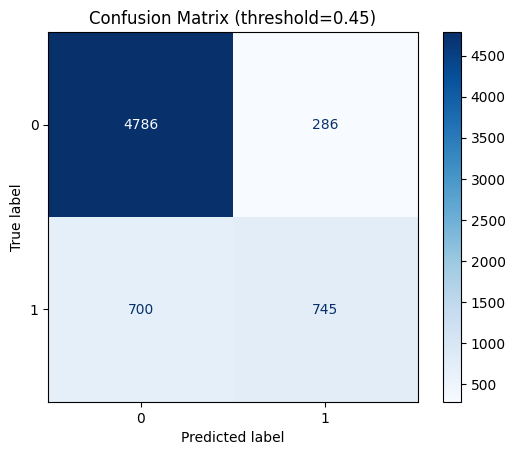

In [47]:
# Нова confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title(f'Confusion Matrix (threshold={best_threshold})')
plt.show()

In [48]:
# Нові метрики
print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall:", recall_score(y_test, y_pred_opt))
print("F1:", f1_score(y_test, y_pred_opt))

Precision: 0.7225994180407371
Recall: 0.5155709342560554
F1: 0.6017770597738288


In [51]:
# Візуалізація
import plotly.express as px

fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах',
    labels={
        'value': 'Значення метрики',
        'threshold': 'Поріг',
        'variable': 'Метрика'
    }
)

fig.add_vline(x=0.45, line_dash="dash", line_color="red",
              annotation_text="Обраний поріг")
fig.show()

**Висновок:** Було змінено поріг класифікації до 0.45 з метою підвищення recall.
Це дозволило збільшити recall з ~0.45 до ~0.52, тобто модель стала краще виявляти позитивний клас.
Кількість пропущених позитивних випадків зменшилась (з 799 до 700), що є важливим для бізнес-задач.
При цьому precision дещо знизився (з ~0.75 до ~0.72), що є очікуваним компромісом.
Загалом F1-score покращився, що свідчить про більш збалансовану модель.

In [53]:
import pandas as pd
import plotly.express as px

# Функція сегментації
def segment_customers(prob):
    if prob < 0.2:
        return 'Низький ризик'
    elif prob < 0.5:
        return 'Середній ризик'
    elif prob < 0.8:
        return 'Високий ризик'
    else:
        return 'Критичний ризик'

# Застосовую до ймовірностей
risk_segments = pd.Series(y_pred_proba[:, 1]).apply(segment_customers).value_counts()

# Сортую
risk_segments = risk_segments.reindex([
    'Низький ризик',
    'Середній ризик',
    'Високий ризик',
    'Критичний ризик'
])

# Pie chart
fig = px.pie(
    values=risk_segments.values,
    names=risk_segments.index,
    title='Розподіл клієнтів за ризиком відтоку',
    color_discrete_sequence=['#27ae60', '#f39c12', '#e67e22', '#e74c3c']
)
fig.update_traces(textinfo='percent+label')

fig.show()

**Висновок:** Більшість клієнтів знаходиться в зоні низького ризику (52.2%), однак близько 21% клієнтів мають високий або критичний ризик відтоку, що потребує активних дій з боку бізнесу.

**Практичні рекомендації для бізнесу**
На основі прогнозованих ймовірностей відтоку було проведено сегментацію клієнтів за рівнем ризику.

Результати сегментації:

```
🟢 Низький ризик — 52.2%
🟡 Середній ризик — 26.8%
🟠 Високий ризик — 17.6%
🔴 Критичний ризик — 3.4%
```

Рекомендована стратегія дій:


```
🔴 Критичний ризик (3.4%)
→ Негайний персональний контакт, індивідуальні пропозиції
🟠 Високий ризик (17.6%)
→ Автоматизовані кампанії (знижки, бонуси)
🟡 Середній ризик (26.8%)
→ Моніторинг поведінки, превентивні заходи
🟢 Низький ризик (52.2%)
→ Стандартне обслуговування
```



Оптимізація порогу класифікації дозволила адаптувати модель під бізнес-цілі та покращити здатність виявляти ризикових клієнтів.
Сегментація клієнтів на основі ймовірності відтоку дає можливість ефективно розподіляти ресурси та застосовувати різні стратегії утримання.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.
